# ==============================================================================
# RESPUESTAS INCISO (A) 
# ==============================================================================

**1. Problema Directo e Inverso:**
Dado que en el problema inverso buscamos construir lo contrario, es decir, inferir $\theta$ a partir de observaciones discretas $x(t_i)$. La dificultad es que en general este problema suele ser **mal planteado**. En otras palabras, la solución puede no ser única, o más críticamente, no depender de forma continua de los datos. Pequeñas perturbaciones $\eta$ en $X$ pueden amplificarse exponencialmente y producir divergencias masivas en el espacio $\Theta$, espacio donde vive $\theta$.

**2. Aprendizaje Supervisado:**
Es absolutamente necesario conocer las etiquetas $\theta_i = (\gamma_i, k_i)$ para el problema inverso puesto que en el aprendizaje supervisado se aproxima $\mathcal{M}^{-1}:\Theta \to X$ mediante una función paramétrica $f_W(x) \approx \theta$ y para optimizar estos pesos $W$ las etiquetas actuan como estado base o real que permite evaluar el gradiente de la función se costo.

**3. Conjuntos de Entrenamiento y Validación:**
Dado que las redes neuronales tienen la capacidad de memorizar el ruido específico del conjunto de datos a entrenar, por lo que guardar una parte de datos como prubea es necesario para medir la capacidad de generalización del modelo y el sobreajuste cuando el error de los datos de entrenamiento converge a 0 pero el error de los datos de prueba diverge.


**4. Función de Pérdida:**
Dado que se requieren métricas diferenciables para optimizar topologías continuas como un MPL. MSE es el análogo discreto de la norma $L_2^2$ en el espacio euclidiano $\mathbb{R}^2$. La elección de un exponente cuadrático castiga severamente las grandes desviaciones algorítmicas y garantiza una superficie de costo localmente convexa cerca de los mínimos, facilitando la convergencia del descenso de gradiente.

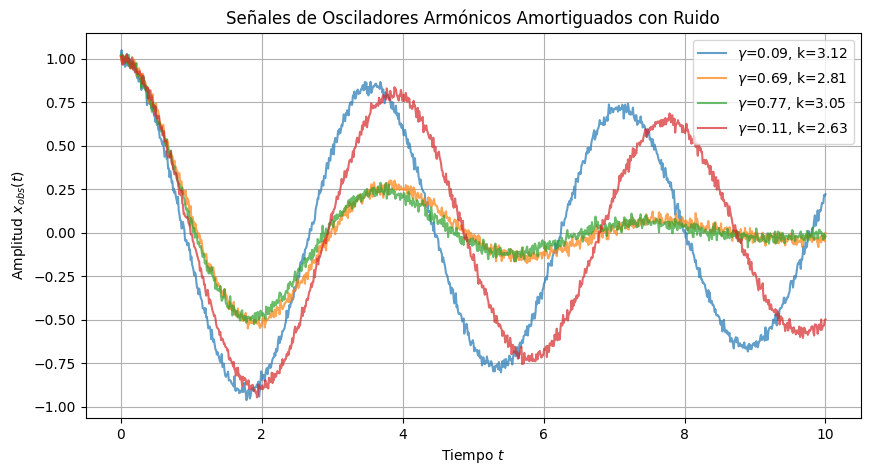

In [3]:
#b- Inicio del código para generación de datos, resolución de EDO y adición de ruido: se parte inicializando los parámetros poblacionales y de dominio
#   los valores de gamma y k se obtienen mediante muestreo estocástico en distribuciones uniformes usando la funcion np.random.uniform.

import numpy as np
import matplotlib.pyplot as plt

N = 3000
N_t = 1000
t_array = np.linspace(0, 10, N_t)
sigma = 0.02
gamma_vals = np.random.uniform(0.05, 1.0, N)
k_vals = np.random.uniform(1.0, 5.0, N)

# Generamos matriz de dimensión (N, N_t) para almacenar las señales limpias de cada oscilador amortiguado
X_clean = np.zeros((N, N_t))

# Resolución de la EDO (con m = 1): dado que gamma = (0.05,1) < k = (1,5)  el discriminante de la ecuación característica es negativo y por ende los autovalores
# son complejos, luego al definir la frecuencia angular del sistema amortiguado w_d = np.sqrt(k - (gamma / 2.0)**2) obtenemos una solución analítica 
# oscilatoria amortiguada de la forma x(t) = exp(-gamma*t/2) * (A*cos(w_d*t) + B*sin(w_d*t)) con A y B determinados por las condiciones iniciales.
# Para el caso específico de x(0)=1 y x'(0)=0, se obtiene A=1 y B=gamma/(2*w_d), lo que da lugar a la expresión final utilizada para generar las señales limpias: np.exp(-gamma * t_array / 2.0) * (
# np.cos(w_d * t_array) + (gamma / (2.0 * w_d)) * np.sin(w_d * t_array) ) .

for i in range(N):
    gamma, k = gamma_vals[i], k_vals[i]
    w_d = np.sqrt(k - (gamma / 2.0)**2) # Frecuencia angular del sistema amortiguado
    X_clean[i, :] = np.exp(-gamma * t_array / 2.0) * (np.cos(w_d * t_array) + (gamma / (2.0 * w_d)) * np.sin(w_d * t_array)) # Solución analítica

# Como se indica se añade un ruido gaussiano con media cero y desv estandar sigma = 0.02 a cada señal limpia para obtener las señales observadas X_obs.
eta = np.random.normal(0, sigma, (N, N_t))
X_obs = X_clean + eta

# Tomamos los 4 primeros osciladores para visualización y graficamos sus señales observadas X_obs[i] en función del tiempo t_array, etiquetando cada curva con los valores correspondientes de gamma y k.
plt.figure(figsize=(10, 5))
indices_plot = [0, 1, 2, 3]
for idx in indices_plot:
    plt.plot(t_array, X_obs[idx], alpha=0.7, 
             label=f'$\gamma$={gamma_vals[idx]:.2f}, k={k_vals[idx]:.2f}')

plt.xlabel('Tiempo $t$')
plt.ylabel('Amplitud $x_{obs}(t)$')
plt.title('Señales de Osciladores Armónicos Amortiguados con Ruido')
plt.legend()
plt.grid(True)
plt.show()

# Al ver la solución analítica presentada es simple reconocer que al variar el parámetro de rigidez k, se aumenta o disminuye directamente la frecuencia de oscilación (w_d proporcional a sqrt(k)). 
# Pero dado el rango en el que se trabaja los autovalores siempre serán complejos y por ende el sistema siempre exhibirá un comportamiento oscilatorio amortiguado. Del mismo modo notamos que 
# al variar el coeficiente de amortiguamiento gamma, se modifica la envolvente exponencial decayente exp(-gamma*t/2), por lo que, valores mayores de gamma inducen una disipación de energía cinética más abrupta.

In [4]:
#c- Inicio del código para entrenamiento de modelos de regresión y evaluación de métricas de error: se parte definiendo la matriz de características Theta con los parámetros gamma y k, luego se realiza una partición del espacio de datos 
#   utilizando test_size=0.2 para reservar el 20% de los datos para evaluación mediante la función train_test_split de sklearn, por lo que queda un 80% para entrenamiento. 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import root_mean_squared_error

Theta = np.column_stack((gamma_vals, k_vals))

X_train, X_test, Theta_train, Theta_test = train_test_split(
    X_obs, Theta, test_size=0.2, random_state=42)

# A continuación se definen y ajustan dos modelos de regresión supervisada para predecir los parámetros gamma y k a partir de las señales observadas X_obs. 1- RandomForestRegressor es un modelo de ensamble basado en 
# árboles de decisión, que construye múltiples árboles (100 en este caso) y promedia sus predicciones para mejorar la precisión y controlar el sobreajuste. 2- MLPRegressor es un modelo de red neuronal de perceptrón 
# multicapa (dos capas ocultas de 100 y 50 neuronas respectivamente), que puede capturar relaciones no lineales complejas entre las características de entrada y las variables objetivo.

#1-
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, Theta_train) # Se ajusta el modelo a los datos de entrenamiento.
Theta_pred_rf = rf_model.predict(X_test) # Se generan predicciones para los datos de prueba utilizando el modelo ajustado.

#2-
mlp_model = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', 
                         solver='adam', max_iter=500, random_state=42)
mlp_model.fit(X_train, Theta_train)
Theta_pred_mlp = mlp_model.predict(X_test)

# Se define la función calcular_rmse para calcular el error cuadrático medio raíz (RMSE) entre los valores verdaderos y las predicciones para ambos parámetros gamma y k.
def calcular_rmse(y_true, y_pred):
    rmse_gamma = root_mean_squared_error(y_true[:, 0], y_pred[:, 0])
    rmse_k = root_mean_squared_error(y_true[:, 1], y_pred[:, 1])
    return rmse_gamma, rmse_k

rmse_rf_gamma, rmse_rf_k = calcular_rmse(Theta_test, Theta_pred_rf)
rmse_mlp_gamma, rmse_mlp_k = calcular_rmse(Theta_test, Theta_pred_mlp)

print(f"Resultados de Inferencia (Ruido σ = {sigma}):")
print("-" * 45)
print(f"RandomForest -> RMSE γ: {rmse_rf_gamma:.4f} | RMSE k: {rmse_rf_k:.4f}")
print(f"MLPRegressor -> RMSE γ: {rmse_mlp_gamma:.4f} | RMSE k: {rmse_mlp_k:.4f}")

Resultados de Inferencia (Ruido σ = 0.02):
---------------------------------------------
RandomForest -> RMSE γ: 0.0150 | RMSE k: 0.0476
MLPRegressor -> RMSE γ: 0.0292 | RMSE k: 0.0411


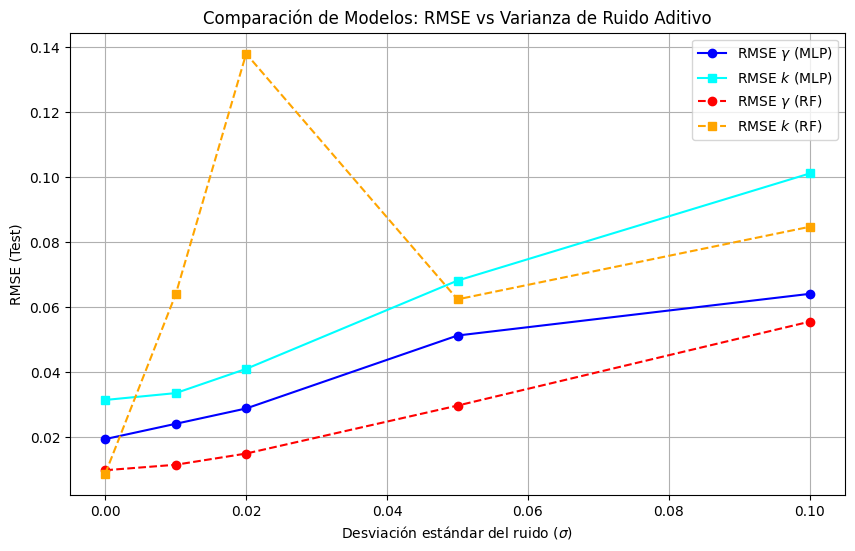

In [ ]:
#d- Se define el vector solicitado de valores de desviación estándar "sigmas" para evaluar la sensibilidad de los modelos a diferentes niveles de ruido. En cada paso, se contamina X_clean con un 
#   nuevo tensor de ruido, se re-entrena el MLP y Random Forest para cada nivel de ruido, y se calcula el RMSE para ambos parámetros gamma y k. Finalmente, se grafican los resultados para comparar 
#   el desempeño de ambos modelos a medida que aumenta la varianza del ruido aditivo.

sigmas= [0, 0.01, 0.02, 0.05, 0.10]
rmse_gamma_rf = []
rmse_k_rf = []
rmse_gamma_mlp = []
rmse_k_mlp = []


for sigma in sigmas:
    X_obs_sigma = X_clean + np.random.normal(0, sigma, (N, N_t)) # se añade la perturbación gaussiana
    
    X_tr, X_ts, y_tr, y_ts = train_test_split(
        X_obs_sigma, Theta, test_size=0.2, random_state=42)

    # Se re-entrenan modelo Random Forest y se guardan los RMSE para gamma y k 
    rf= RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pr_rf = rf.predict(X_ts)
    r_gamma_rf, r_k_rf = calcular_rmse(y_ts, y_pr_rf)
    rmse_gamma_rf.append(r_gamma_rf)
    rmse_k_rf.append(r_k_rf)

    # Se re-entrenan modelo MLP y se guardan los RMSE para gamma y k 
    mlp = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=500, random_state=42)
    mlp.fit(X_tr, y_tr)
    y_pr_mlp = mlp.predict(X_ts)
    r_gamma, r_k = calcular_rmse(y_ts, y_pr_mlp)

    rmse_gamma_mlp.append(r_gamma)
    rmse_k_mlp.append(r_k)

# graficamos los resultados de RMSE en funcion de sigma para ambos modelos y ambos parámetros
plt.figure(figsize=(10, 6))

plt.plot(sigmas, rmse_gamma_mlp, 'o-', color='blue', label='RMSE $\gamma$ (MLP)')
plt.plot(sigmas, rmse_k_mlp, 's-', color='cyan', label='RMSE $k$ (MLP)')

plt.plot(sigmas, rmse_gamma_rf, 'o--', color='red', label='RMSE $\gamma$ (RF)')
plt.plot(sigmas, rmse_k_rf, 's--', color='orange', label='RMSE $k$ (RF)')

plt.xlabel('Desviación estándar del ruido ($\sigma$)')
plt.ylabel('RMSE (Test)')
plt.title('Comparación de Modelos: RMSE vs Varianza de Ruido Aditivo')
plt.legend()
plt.grid(True)
plt.show()



# 1. Sensibilidad de los parámetros físicos:
# Los resultados muestran que inferir la rigidez 'k' es notablemente más difícil 
# que inferir el amortiguamiento '\gamma' tanto para bajos como para altos niveles de ruido en ambos modelos.
# Físicamente, esto ocurre porque el ruido enmascara la frecuencia de oscilación (gobernada por k) de manera mucho más 
# agresiva que la envolvente general de decaimiento (gobernada por \gamma).
#
# 2. Desempeño de los modelos y Sobreajuste:
# Ambos modelos reaccionan de forma diametralmente opuesta ante el ruido:
#
# - MLPRegressor (Red Neuronal): 
#   Demuestra una excelente capacidad de generalización. La estructura de la red 
#   actúa naturalmente como un filtro que suaviza los datos. Esto permite que el 
#   modelo logre capturar la dinámica real de la ecuación diferencial en lugar 
#   de confundirse con las alteraciones aleatorias.
#
# - RandomForestRegressor (Árboles de Decisión): 
#   Sufre un sobreajuste severo. Debido a que este modelo toma decisiones fijándose 
#   en la amplitud exacta de la señal en instantes de tiempo específicos, termina 
#   "memorizando" el ruido de los datos de entrenamiento. Al evaluar el conjunto 
#   de prueba, estas reglas memorizadas fallan, disparando el error a medida que 
#   crece la intensidad del ruido.